# KPX 한국전력거래소 — 시간별 전국 전력수요량 EDA

In [2]:
import sys
sys.path.insert(0, "..")  # 루트 config.py 접근

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from config import DATA_DIR, DATE_COL, HOUR_COLS, CSV_ENCODING

plt.rcParams["font.family"] = "AppleGothic"   # macOS 한글 폰트
plt.rcParams["axes.unicode_minus"] = False

## 1. 데이터 로드 및 전처리

In [3]:
csv_path = next(DATA_DIR.glob("*.csv"))
print(f"파일: {csv_path.name}")

wide = pd.read_csv(csv_path, encoding=CSV_ENCODING, parse_dates=[DATE_COL])
wide[HOUR_COLS] = wide[HOUR_COLS].apply(pd.to_numeric, errors="coerce")
print(wide.shape)
wide.head(3)

파일: 한국전력거래소_시간별 전국 전력수요량_20251231.csv
(366, 25)


,날짜,1시,2시,3시,4시,5시,6시,7시,8시,9시,...,15시,16시,17시,18시,19시,20시,21시,22시,23시,24시
0,2025-01-01,62256.0,59663.0,57880.0,57098.0,56966.0,57442.0,58338.0,58868.0,58090.0,...,49914.0,53489.0,58061.0,62545.0,64403.0,64403.0,63653.0,62722.0,62249.0,61871.0
1,2025-01-02,59219.0,57092.0,55931.0,55597.0,56374.0,58691.0,63081.0,70103.0,77832.0,...,70016.0,73169.0,76318.0,77503.0,76379.0,74902.0,72276.0,69663.0,69473.0,68787.0
2,2025-01-03,65330.0,63074.0,61755.0,60993.0,61499.0,63432.0,67664.0,74049.0,80523.0,...,73431.0,76306.0,78869.0,79167.0,77242.0,75448.0,73036.0,70538.0,70455.0,69823.0


In [4]:
# wide → long (날짜+시간 → 단일 datetime 인덱스)
long = wide.melt(id_vars=DATE_COL, value_vars=HOUR_COLS, var_name="시간", value_name="수요량(MW)")
long["hour"] = long["시간"].str.replace("시", "").astype(int) - 1  # 0~23
long["datetime"] = long[DATE_COL] + pd.to_timedelta(long["hour"], unit="h")
long = long.sort_values("datetime").set_index("datetime")[["수요량(MW)"]]

print(f"총 {len(long)}개 포인트 | {long.index.min()} ~ {long.index.max()}")
long.describe()

총 8784개 포인트 | 2025-01-01 00:00:00 ~ 2025-12-31 23:00:00


,수요량(MW)
count,8760.000000
mean,64503.260274
std,10116.983596
min,35811.000000
25%,57107.500000
50%,63400.000000
75%,71079.500000
max,95951.000000


## 2. 전체 시계열

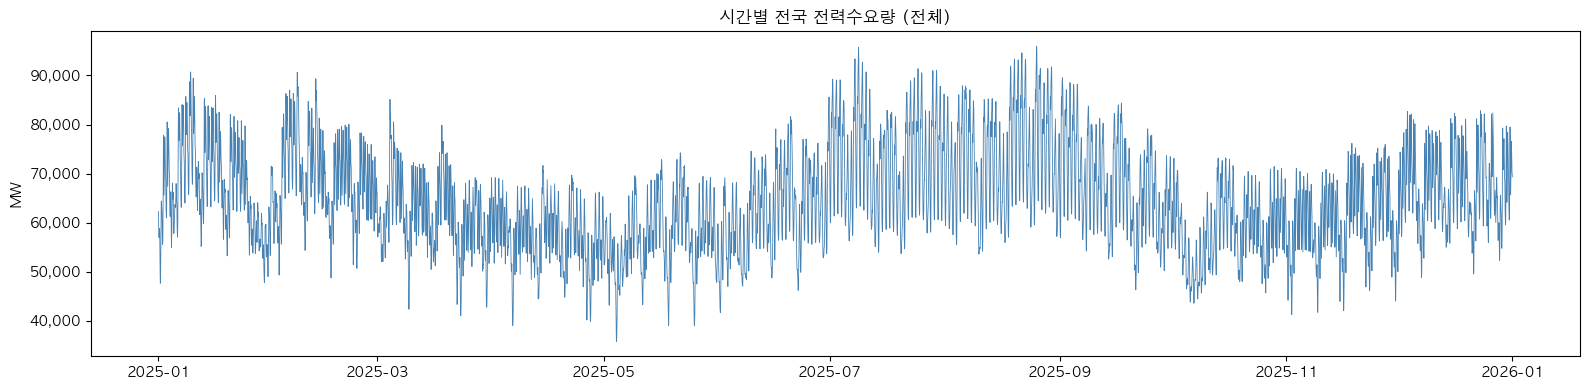

In [5]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(long.index, long["수요량(MW)"], linewidth=0.6, color="steelblue")
ax.set_title("시간별 전국 전력수요량 (전체)")
ax.set_ylabel("MW")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## 3. 일간 주기 패턴 (시간대별 평균)

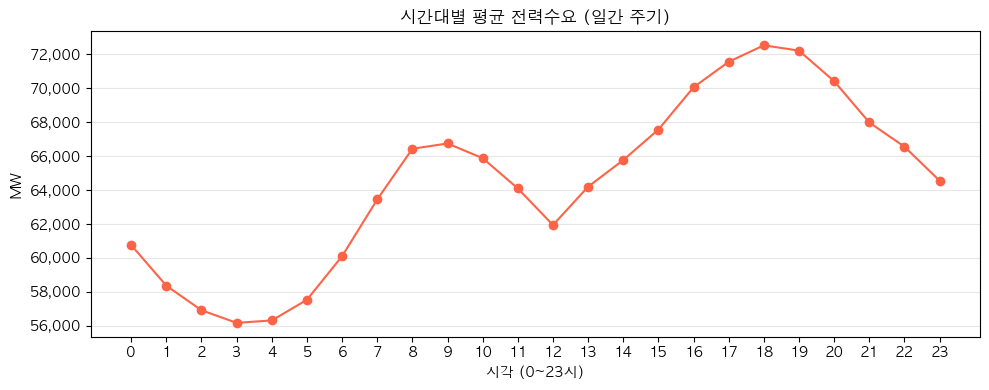

In [6]:
hourly_mean = long.groupby(long.index.hour)["수요량(MW)"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_mean.index, hourly_mean.values, marker="o", color="tomato")
ax.set_title("시간대별 평균 전력수요 (일간 주기)")
ax.set_xlabel("시각 (0~23시)")
ax.set_ylabel("MW")
ax.set_xticks(range(24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 주간 주기 패턴 (요일별 평균)

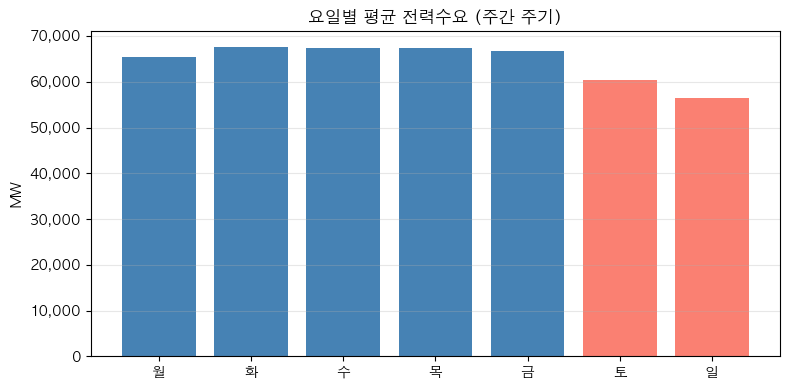

In [7]:
day_labels = ["월", "화", "수", "목", "금", "토", "일"]
daily_mean = long.groupby(long.index.dayofweek)["수요량(MW)"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(day_labels, daily_mean.values, color=["steelblue"]*5 + ["salmon"]*2)
ax.set_title("요일별 평균 전력수요 (주간 주기)")
ax.set_ylabel("MW")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 히트맵 (요일 × 시간대)

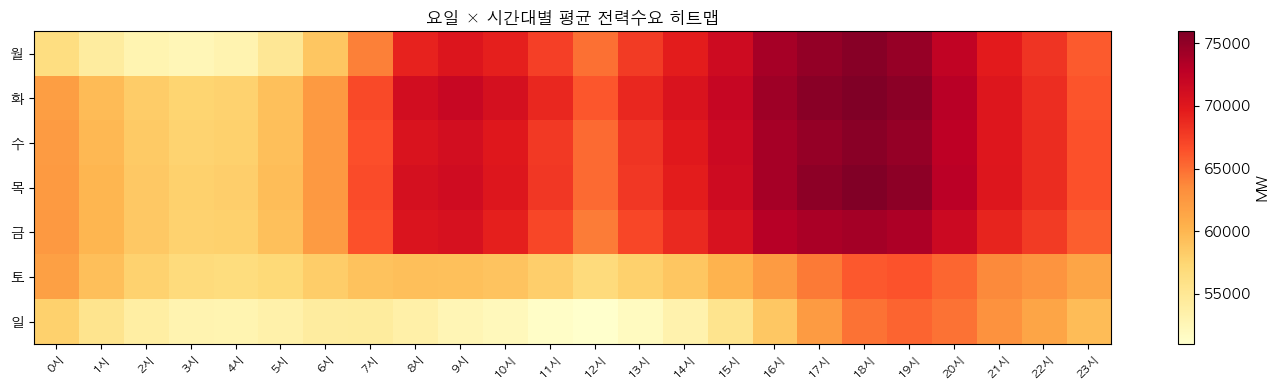

In [8]:
pivot = long.copy()
pivot["hour"] = pivot.index.hour
pivot["dayofweek"] = pivot.index.dayofweek
heatmap = pivot.groupby(["dayofweek", "hour"])["수요량(MW)"].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(heatmap.values, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(7))
ax.set_yticklabels(day_labels)
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h}시" for h in range(24)], rotation=45, fontsize=8)
ax.set_title("요일 × 시간대별 평균 전력수요 히트맵")
plt.colorbar(im, ax=ax, label="MW")
plt.tight_layout()
plt.show()

## 6. 월별 평균 (계절 패턴)

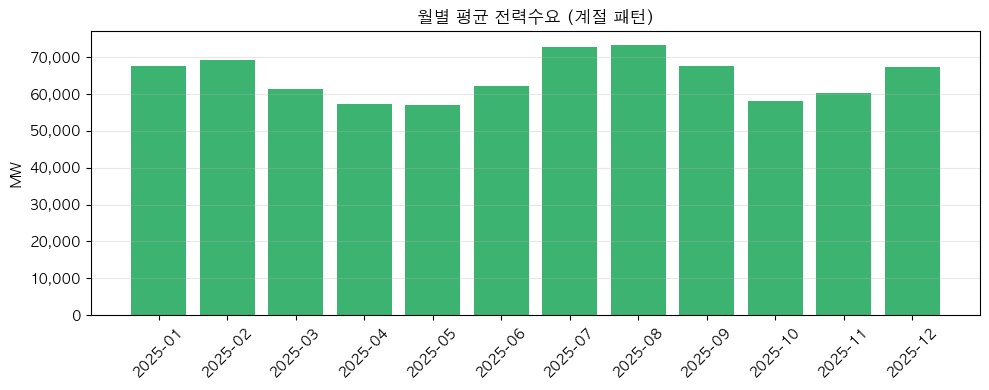

In [9]:
monthly = long.resample("ME")["수요량(MW)"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly.index.strftime("%Y-%m"), monthly.values, color="mediumseagreen")
ax.set_title("월별 평균 전력수요 (계절 패턴)")
ax.set_ylabel("MW")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 연간 주기 패턴 (7일 단위 평균)

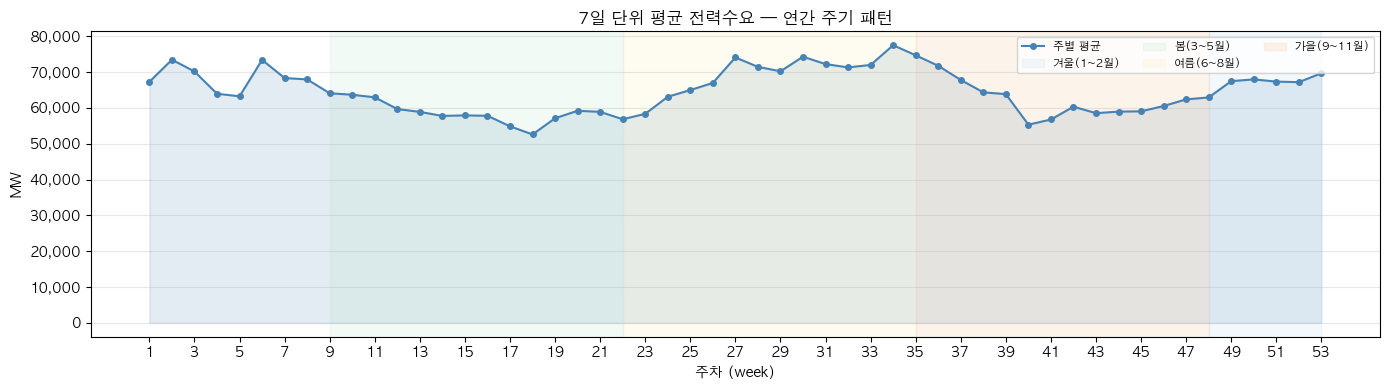

In [10]:
# 7일(168h) 단위로 묶어 주별 평균 → 연간 흐름
weekly = long.resample("7D")["수요량(MW)"].mean()
week_num = np.arange(1, len(weekly) + 1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(week_num, weekly.values, marker="o", markersize=4, color="steelblue", label="주별 평균")
ax.fill_between(week_num, weekly.values, alpha=0.15, color="steelblue")

# 계절 구분선
seasons = {"겨울": (1, 9), "봄": (9, 22), "여름": (22, 35), "가을": (35, 48), "겨울": (48, 53)}
colors  = ["#aed6f1", "#a9dfbf", "#f9e79f", "#f0b27a", "#aed6f1"]
labels  = ["겨울(1~2월)", "봄(3~5월)", "여름(6~8월)", "가을(9~11월)", "겨울(12월)"]
for (_, (s, e)), c, lbl in zip(seasons.items(), colors, labels):
    ax.axvspan(s, min(e, len(weekly)), alpha=0.15, color=c, label=lbl)

ax.set_title("7일 단위 평균 전력수요 — 연간 주기 패턴")
ax.set_xlabel("주차 (week)")
ax.set_ylabel("MW")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticks(week_num[::2])
ax.legend(loc="upper right", fontsize=8, ncol=3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()